# 🍽️ Zomato Restaurant Data Analysis

## 📌 Project Overview

This project analyzes Zomato restaurant data from across India to identify trends in restaurant distribution, cuisines, pricing, ratings, and customer preferences. The objective is to derive meaningful business insights using Python, Pandas, Matplotlib, and Power BI.

## 🎯 Objectives

- Analyze restaurant distribution across cities
- Identify the most popular cuisines
- Study restaurant ratings
- Analyze pricing trends
- Compare ratings with pricing
- Evaluate delivery services
- Generate business recommendations

## 🛠️ Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook
- Power BI
- Git & GitHub

## 📂 Dataset

Source: Kaggle - Zomato Restaurants in India Dataset

In [1]:
import pandas as pd
import numpy as np

In [3]:
import os

os.listdir("../data")

['zomato_restaurants_in_India.csv']

In [8]:
import os
print(os.getcwd())



c:\Users\Tanishka Singh\Downloads\Zomato-data-analysis\notebook


In [ ]:
import os

print(os.listdir())

['zomato_analysis.ipynb']


In [10]:
print(os.listdir("../"))

['dashboard', 'data', 'images', 'notebook', 'report', 'requirements.tx', 'requirements.txt', 'sql', 'venv']


In [12]:
import os

print(os.listdir("../data"))

['zomato_raw..csv']


In [13]:
import os
print(os.listdir("../data"))

['zomato_raw.csv']


In [14]:
df = pd.read_csv("../data/zomato_raw.csv")

In [15]:
df.head()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,1,-1


In [16]:
df.shape

(211944, 26)

In [17]:
df.columns

Index(['res_id', 'name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='str')

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211944 entries, 0 to 211943
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   res_id                211944 non-null  int64  
 1   name                  211944 non-null  str    
 2   establishment         211944 non-null  str    
 3   url                   211944 non-null  str    
 4   address               211810 non-null  str    
 5   city                  211944 non-null  str    
 6   city_id               211944 non-null  int64  
 7   locality              211944 non-null  str    
 8   latitude              211944 non-null  float64
 9   longitude             211944 non-null  float64
 10  zipcode               48757 non-null   str    
 11  country_id            211944 non-null  int64  
 12  locality_verbose      211944 non-null  str    
 13  cuisines              210553 non-null  str    
 14  timings               208070 non-null  str    
 15  average_cos

In [19]:
df.isnull().sum()

res_id                       0
name                         0
establishment                0
url                          0
address                    134
city                         0
city_id                      0
locality                     0
latitude                     0
longitude                    0
zipcode                 163187
country_id                   0
locality_verbose             0
cuisines                  1391
timings                   3874
average_cost_for_two         0
price_range                  0
currency                     0
highlights                   0
aggregate_rating             0
rating_text                  0
votes                        0
photo_count                  0
opentable_support           48
delivery                     0
takeaway                     0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(151527)

In [21]:
df[df.duplicated()].head()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
101,3400059,Peshawri - ITC Mughal,['Fine Dining'],https://www.zomato.com/agra/peshawri-itc-mugha...,"ITC Mughal, Fatehabad Road, Tajganj, Agra",Agra,34,"ITC Mughal, Tajganj",27.161150,78.043993,...,4,Rs.,"['Lunch', 'Cash', 'Credit Card', 'Dinner', 'De...",4.4,Very Good,353,154,0.0,-1,-1
116,3400060,Taj Bano - ITC Mughal,['Fine Dining'],https://www.zomato.com/agra/taj-bano-itc-mugha...,"ITC Mughal, Fatehabad Road, Tajganj, Agra",Agra,34,"ITC Mughal, Tajganj",27.161132,78.044022,...,4,Rs.,"['Credit Card', 'Lunch', 'Cash', 'Debit Card',...",4.3,Very Good,96,205,0.0,-1,-1
140,3400017,Pinch Of Spice,['Casual Dining'],https://www.zomato.com/agra/pinch-of-spice-civ...,"23/453, Opposite Sanjay Cinema, Wazipura Road,...",Agra,34,Civil Lines,27.201735,78.007625,...,4,Rs.,"['Lunch', 'Delivery', 'Credit Card', 'Dinner',...",4.6,Excellent,915,105,0.0,1,-1
141,3400018,Pinch Of Spice,['Casual Dining'],https://www.zomato.com/agra/pinch-of-spice-taj...,"1076/2, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.159649,78.043304,...,4,Rs.,"['Delivery', 'Dinner', 'Cash', 'Credit Card', ...",4.6,Excellent,965,690,0.0,1,-1
142,3400850,Urban Deck,['Casual Dining'],https://www.zomato.com/agra/urban-deck-2-civil...,"5th Floor, The P L Palace Hotel, MG Road, Sanj...",Agra,34,Civil Lines,27.199573,78.003699,...,4,Rs.,"['Dinner', 'Cash', 'Debit Card', 'Takeaway Ava...",4.3,Very Good,672,192,0.0,1,-1


In [22]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())

Total rows: 211944
Duplicate rows: 151527


In [23]:
df[df.duplicated()].head(10)

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
101,3400059,Peshawri - ITC Mughal,['Fine Dining'],https://www.zomato.com/agra/peshawri-itc-mugha...,"ITC Mughal, Fatehabad Road, Tajganj, Agra",Agra,34,"ITC Mughal, Tajganj",27.161150,78.043993,...,4,Rs.,"['Lunch', 'Cash', 'Credit Card', 'Dinner', 'De...",4.4,Very Good,353,154,0.0,-1,-1
116,3400060,Taj Bano - ITC Mughal,['Fine Dining'],https://www.zomato.com/agra/taj-bano-itc-mugha...,"ITC Mughal, Fatehabad Road, Tajganj, Agra",Agra,34,"ITC Mughal, Tajganj",27.161132,78.044022,...,4,Rs.,"['Credit Card', 'Lunch', 'Cash', 'Debit Card',...",4.3,Very Good,96,205,0.0,-1,-1
140,3400017,Pinch Of Spice,['Casual Dining'],https://www.zomato.com/agra/pinch-of-spice-civ...,"23/453, Opposite Sanjay Cinema, Wazipura Road,...",Agra,34,Civil Lines,27.201735,78.007625,...,4,Rs.,"['Lunch', 'Delivery', 'Credit Card', 'Dinner',...",4.6,Excellent,915,105,0.0,1,-1
141,3400018,Pinch Of Spice,['Casual Dining'],https://www.zomato.com/agra/pinch-of-spice-taj...,"1076/2, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.159649,78.043304,...,4,Rs.,"['Delivery', 'Dinner', 'Cash', 'Credit Card', ...",4.6,Excellent,965,690,0.0,1,-1
142,3400850,Urban Deck,['Casual Dining'],https://www.zomato.com/agra/urban-deck-2-civil...,"5th Floor, The P L Palace Hotel, MG Road, Sanj...",Agra,34,Civil Lines,27.199573,78.003699,...,4,Rs.,"['Dinner', 'Cash', 'Debit Card', 'Takeaway Ava...",4.3,Very Good,672,192,0.0,1,-1
143,3401344,Cafe Turquoise Cottage,['Casual Dining'],https://www.zomato.com/agra/cafe-turquoise-cot...,"76, 2nd floor, Fatehabad Road, Near Amar Hotel...",Agra,34,Tajganj,27.161003,78.031400,...,4,Rs.,"['Lunch', 'Serves Alcohol', 'Takeaway Availabl...",4.6,Excellent,344,267,0.0,-1,-1
144,3401656,D'Delicia,['Casual Dining'],https://www.zomato.com/agra/ddelicia-tajganj?u...,"E-4/B, Taj Nagari Phase-2, Near Hotel Courtyar...",Agra,34,Tajganj,27.154175,78.059131,...,4,Rs.,"['Lunch', 'Takeaway Available', 'Debit Card', ...",4.7,Excellent,252,235,0.0,1,-1
147,3400853,Mocha,['Café'],https://www.zomato.com/agra/mocha-tajganj?utm_...,"1448 - 1453 tajganj, Fatehabad Road, Tajganj Agra",Agra,34,Tajganj,27.157950,78.051030,...,4,Rs.,"['Dinner', 'Cash', 'Takeaway Available', 'Debi...",4.4,Very Good,463,482,0.0,-1,-1
148,3400780,Grey House Cafe,['Café'],https://www.zomato.com/agra/grey-house-cafe-ta...,"Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157660,78.050503,...,4,Rs.,"['Dinner', 'Serves Alcohol', 'Cash', 'Takeaway...",4.1,Very Good,208,224,0.0,-1,-1
171,3400868,Hichkee,['Casual Dining'],https://www.zomato.com/agra/hichkee-civil-line...,"6/27/1A, Hotel Alleviate, Yamuna Kinara Road, ...",Agra,34,Civil Lines,27.190041,78.024693,...,3,Rs.,"['Dinner', 'Delivery', 'Credit Card', 'Lunch',...",4.4,Very Good,683,229,0.0,1,-1


In [24]:
df.nunique()

res_id                  55568
name                    41100
establishment              27
url                     55568
address                 50657
city                       99
city_id                    83
locality                 3731
latitude                53362
longitude               53326
zipcode                  1311
country_id                  1
locality_verbose         3910
cuisines                 9382
timings                  7740
average_cost_for_two      145
price_range                 4
currency                    1
highlights              31455
aggregate_rating           33
rating_text                39
votes                    2644
photo_count              2514
opentable_support           1
delivery                    3
takeaway                    1
dtype: int64

In [25]:
df["res_id"].value_counts().head(10)

res_id
18631911    169
68976       161
18598737    156
72245       154
18921640    154
18818786    152
73088       151
18593024    150
73211       150
18674729    150
Name: count, dtype: int64

In [26]:
df["res_id"].value_counts().head(10)

res_id
18631911    169
68976       161
18598737    156
72245       154
18921640    154
18818786    152
73088       151
18593024    150
73211       150
18674729    150
Name: count, dtype: int64

In [27]:
df_unique = df.drop_duplicates(subset="res_id", keep="first")

print("Original rows:", len(df))
print("Rows after removing duplicate restaurant IDs:", len(df_unique))
print("Unique restaurant IDs:", df["res_id"].nunique())

Original rows: 211944
Rows after removing duplicate restaurant IDs: 55568
Unique restaurant IDs: 55568


In [28]:
df[df["res_id"] == 18631911]

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
33504,18631911,"3B's - Buddies, Bar & Barbecue",['Casual Dining'],https://www.zomato.com/chennai/3bs-buddies-bar...,"1, Hanumantha Road, Near Soma Sunder Ground, T...",Chennai,7,T. Nagar,13.045373,80.233004,...,3,Rs.,"['Takeaway Available', 'Dinner', 'Lunch', 'Cas...",4.5,Excellent,1553,328,0.0,-1,-1
33606,18631911,"3B's - Buddies, Bar & Barbecue",['Casual Dining'],https://www.zomato.com/chennai/3bs-buddies-bar...,"1, Hanumantha Road, Near Soma Sunder Ground, T...",Chennai,7,T. Nagar,13.045373,80.233004,...,3,Rs.,"['Takeaway Available', 'Dinner', 'Lunch', 'Cas...",4.5,Excellent,1553,328,0.0,-1,-1
33706,18631911,"3B's - Buddies, Bar & Barbecue",['Casual Dining'],https://www.zomato.com/chennai/3bs-buddies-bar...,"1, Hanumantha Road, Near Soma Sunder Ground, T...",Chennai,7,T. Nagar,13.045373,80.233004,...,3,Rs.,"['Takeaway Available', 'Dinner', 'Lunch', 'Cas...",4.5,Excellent,1553,328,0.0,-1,-1
33786,18631911,"3B's - Buddies, Bar & Barbecue",['Casual Dining'],https://www.zomato.com/chennai/3bs-buddies-bar...,"1, Hanumantha Road, Near Soma Sunder Ground, T...",Chennai,7,T. Nagar,13.045373,80.233004,...,3,Rs.,"['Takeaway Available', 'Dinner', 'Lunch', 'Cas...",4.5,Excellent,1553,328,0.0,-1,-1
33875,18631911,"3B's - Buddies, Bar & Barbecue",['Casual Dining'],https://www.zomato.com/chennai/3bs-buddies-bar...,"1, Hanumantha Road, Near Soma Sunder Ground, T...",Chennai,7,T. Nagar,13.045373,80.233004,...,3,Rs.,"['Takeaway Available', 'Dinner', 'Lunch', 'Cas...",4.5,Excellent,1553,328,0.0,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43788,18631911,"3B's - Buddies, Bar & Barbecue",['Casual Dining'],https://www.zomato.com/chennai/3bs-buddies-bar...,"1, Hanumantha Road, Near Soma Sunder Ground, T...",Chennai,7,T. Nagar,13.045373,80.233004,...,3,Rs.,"['Takeaway Available', 'Dinner', 'Lunch', 'Cas...",4.5,Excellent,1553,328,0.0,-1,-1
43818,18631911,"3B's - Buddies, Bar & Barbecue",['Casual Dining'],https://www.zomato.com/chennai/3bs-buddies-bar...,"1, Hanumantha Road, Near Soma Sunder Ground, T...",Chennai,7,T. Nagar,13.045373,80.233004,...,3,Rs.,"['Takeaway Available', 'Dinner', 'Lunch', 'Cas...",4.5,Excellent,1553,328,0.0,-1,-1
43848,18631911,"3B's - Buddies, Bar & Barbecue",['Casual Dining'],https://www.zomato.com/chennai/3bs-buddies-bar...,"1, Hanumantha Road, Near Soma Sunder Ground, T...",Chennai,7,T. Nagar,13.045373,80.233004,...,3,Rs.,"['Takeaway Available', 'Dinner', 'Lunch', 'Cas...",4.5,Excellent,1553,328,0.0,-1,-1
43890,18631911,"3B's - Buddies, Bar & Barbecue",['Casual Dining'],https://www.zomato.com/chennai/3bs-buddies-bar...,"1, Hanumantha Road, Near Soma Sunder Ground, T...",Chennai,7,T. Nagar,13.045373,80.233004,...,3,Rs.,"['Takeaway Available', 'Dinner', 'Lunch', 'Cas...",4.5,Excellent,1553,328,0.0,-1,-1


In [29]:
df = df.drop_duplicates(subset="res_id", keep="first")

In [30]:
print(df.shape)

(55568, 26)


In [31]:
df.to_csv("../data/zomato_cleaned.csv", index=False)

In [32]:
city_counts = df["city"].value_counts()

city_counts.head(10)

city
Bangalore    2247
Mumbai       2022
Pune         1843
Chennai      1827
New Delhi    1704
Jaipur       1395
Kolkata      1361
Ahmedabad    1247
Goa          1150
Lucknow      1135
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


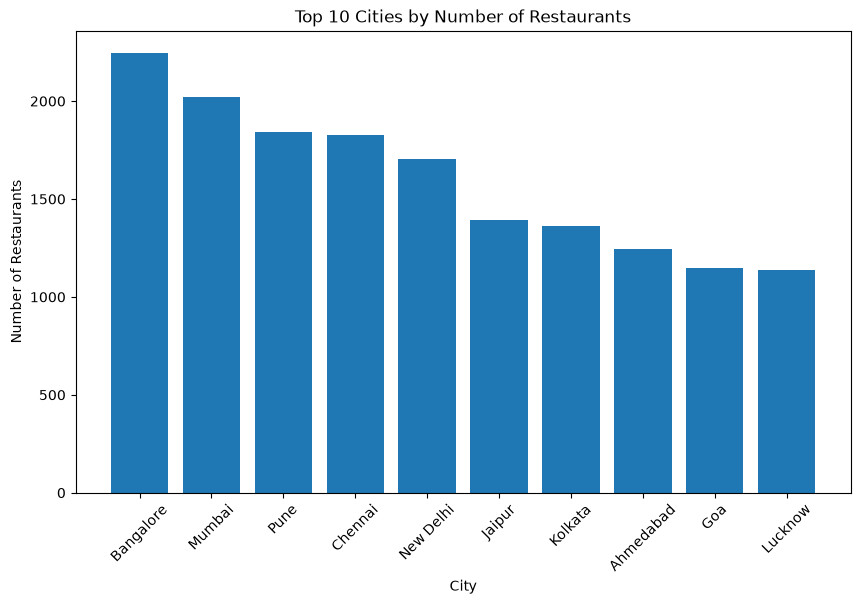

In [33]:
import matplotlib.pyplot as plt

top10_cities = df["city"].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_cities.index, top10_cities.values)

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

## Analysis 1: Top 10 Cities by Number of Restaurants

### Business Question
Which cities have the highest number of restaurants listed on Zomato?

### Observation
- Bangalore has the highest number of restaurants.
- Mumbai ranks second.
- Pune and Chennai also have a strong restaurant presence.
- New Delhi is among the top five cities.

### Business Insight
The restaurant market is highly concentrated in metropolitan cities. Businesses planning to expand through Zomato can prioritize these cities due to their large customer base and high restaurant density.

In [34]:
df["cuisines"].head()

0    North Indian, South Indian, Mithai, Street Foo...
1    North Indian, Mughlai, Rolls, Chinese, Fast Fo...
2                                    Fast Food, Mithai
3            Desserts, Bakery, Fast Food, South Indian
4                   North Indian, Continental, Italian
Name: cuisines, dtype: str

In [35]:
all_cuisines = (
    df["cuisines"]
    .dropna()
    .str.split(", ")
    .explode()
)

all_cuisines.head(10)

0    North Indian
0    South Indian
0          Mithai
0     Street Food
0        Desserts
1    North Indian
1         Mughlai
1           Rolls
1         Chinese
1       Fast Food
Name: cuisines, dtype: str

In [36]:
top_cuisines = all_cuisines.value_counts().head(15)

top_cuisines

cuisines
North Indian    19226
Chinese         12724
Fast Food       11988
Desserts         7064
Beverages        6754
South Indian     6381
Continental      5076
Bakery           4813
Cafe             4252
Street Food      3715
Italian          3673
Biryani          3207
Mithai           3144
Ice Cream        3053
Pizza            2461
Name: count, dtype: int64

In [37]:
all_cuisines.value_counts()

cuisines
North Indian     19226
Chinese          12724
Fast Food        11988
Desserts          7064
Beverages         6754
                 ...  
Garhwali             2
Mandi                1
International        1
Swedish              1
Vegan                1
Name: count, Length: 133, dtype: int64

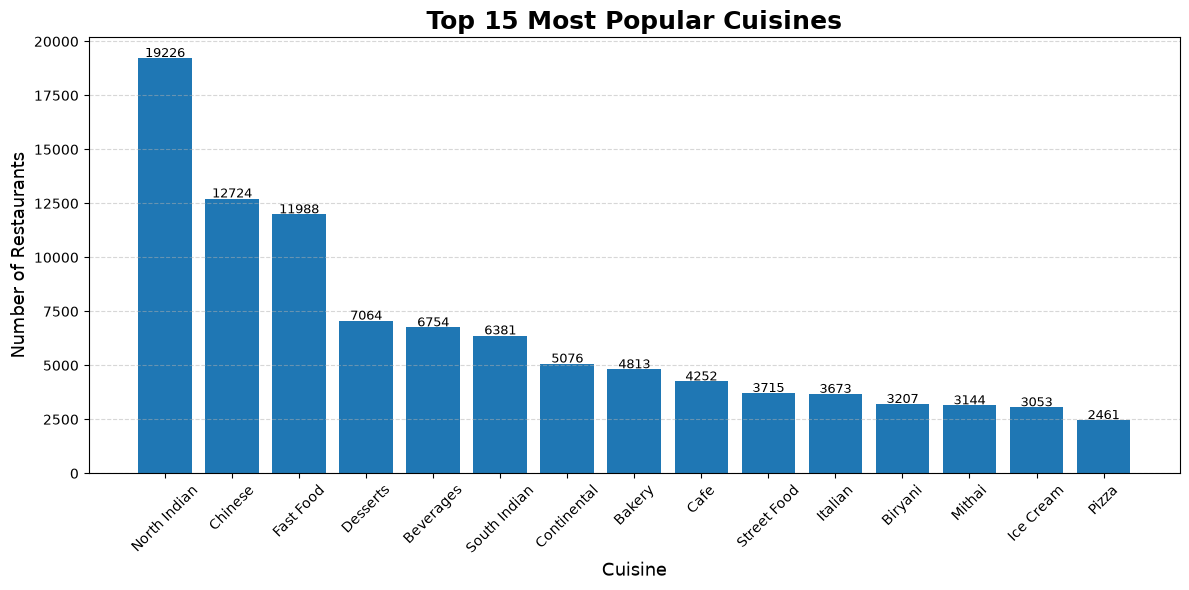

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

bars = plt.bar(top_cuisines.index, top_cuisines.values)

plt.title("Top 15 Most Popular Cuisines", fontsize=18, fontweight='bold')
plt.xlabel("Cuisine", fontsize=13)
plt.ylabel("Number of Restaurants", fontsize=13)

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        int(bar.get_height()),
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Analysis 2: Most Popular Cuisines

### Business Question
Which cuisines are served by the highest number of restaurants on Zomato?

### Observation
- North Indian cuisine is served by the largest number of restaurants.
- Chinese cuisine is also highly popular across cities.
- Fast Food, Cafe, South Indian, and Continental are among the most common cuisines.

### Business Insight
Restaurants serving popular cuisines have a larger market presence. Businesses planning to open new restaurants should consider offering high-demand cuisines or combining popular cuisine categories to attract more customers.

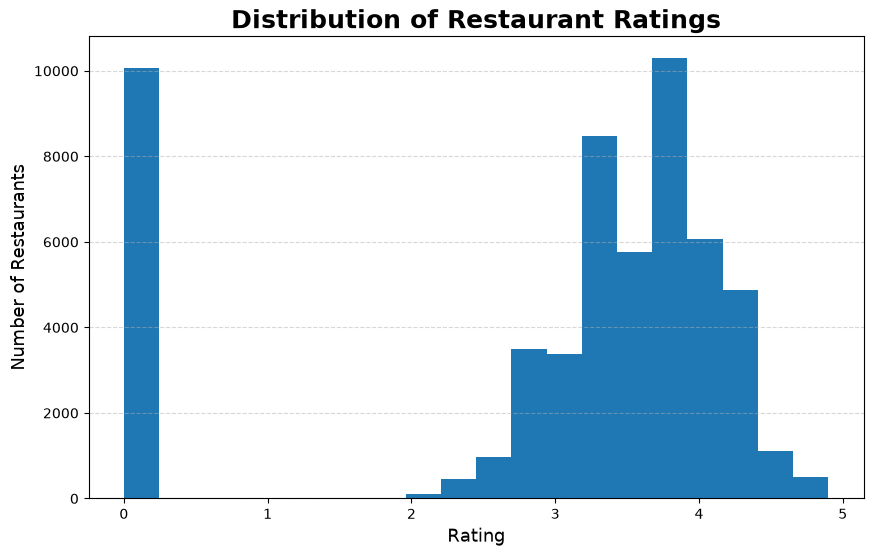

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(df["aggregate_rating"], bins=20)

plt.title("Distribution of Restaurant Ratings", fontsize=18, fontweight="bold")
plt.xlabel("Rating", fontsize=13)
plt.ylabel("Number of Restaurants", fontsize=13)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(df["aggregate_rating"], bins=20)

plt.title("Distribution of Restaurant Ratings", fontsize=18, fontweight="bold")
plt.xlabel("Rating", fontsize=13)
plt.ylabel("Number of Restaurants", fontsize=13)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

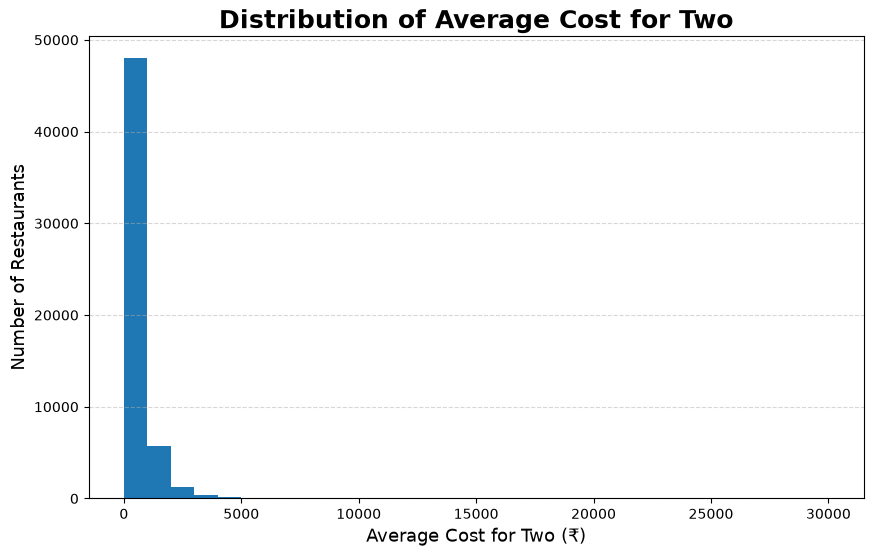

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(df["average_cost_for_two"], bins=30)

plt.title("Distribution of Average Cost for Two", fontsize=18, fontweight="bold")
plt.xlabel("Average Cost for Two (₹)", fontsize=13)
plt.ylabel("Number of Restaurants", fontsize=13)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

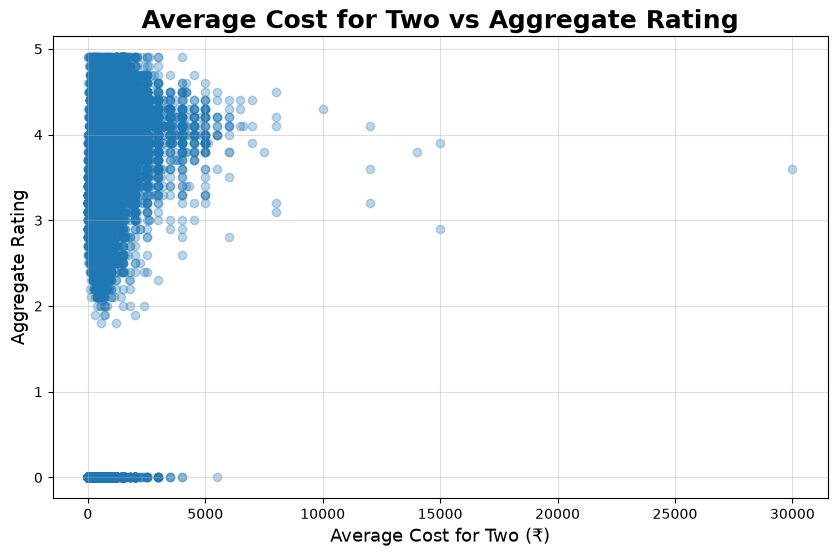

In [41]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["average_cost_for_two"],
    df["aggregate_rating"],
    alpha=0.3
)

plt.title("Average Cost for Two vs Aggregate Rating", fontsize=18, fontweight="bold")
plt.xlabel("Average Cost for Two (₹)", fontsize=13)
plt.ylabel("Aggregate Rating", fontsize=13)

plt.grid(alpha=0.4)

plt.show()

## Analysis 5: Rating vs Average Cost

### Business Question
Is there a relationship between restaurant pricing and customer ratings?

### Observation
- Each point represents one restaurant.
- Most restaurants are concentrated in the lower to mid-price range.
- Higher-priced restaurants do not always receive higher ratings.

### Business Insight
Restaurant quality, as reflected by customer ratings, is not solely determined by pricing. Budget-friendly restaurants can achieve ratings comparable to premium restaurants by focusing on food quality and customer experience.

In [42]:
df["delivery"].value_counts()

delivery
-1    37346
 1    17907
 0      315
Name: count, dtype: int64

In [52]:
delivery_df = df[df["delivery"] != 0]

In [53]:
delivery_rating = delivery_df.groupby("delivery")["aggregate_rating"].mean()

delivery_rating

delivery
-1    2.712039
 1    3.475306
Name: aggregate_rating, dtype: float64

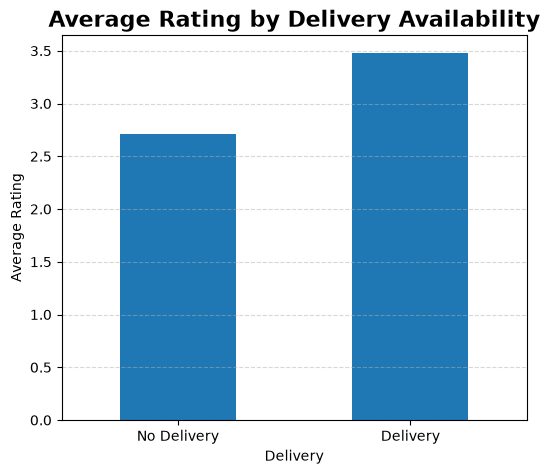

In [54]:
plt.figure(figsize=(6,5))

delivery_rating.plot(kind="bar")

plt.title("Average Rating by Delivery Availability", fontsize=16, fontweight="bold")
plt.xlabel("Delivery")
plt.ylabel("Average Rating")

plt.xticks([0, 1], ["No Delivery", "Delivery"], rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## Analysis 6: Delivery vs Rating

### Business Question
Do restaurants offering delivery receive higher customer ratings?

### Observation
- The chart compares the average ratings of restaurants with and without delivery.
- The difference in ratings indicates whether delivery service has an association with customer satisfaction.

### Business Insight
Offering delivery alone does not guarantee higher customer ratings. Restaurant quality, food consistency, and service remain the primary factors influencing customer satisfaction.

In [55]:
import seaborn as sns

In [56]:
city_cost = (
    df.groupby("city")["average_cost_for_two"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

city_cost

city
Mumbai         1075.098912
New Delhi       994.870892
Gurgaon         982.262295
Hyderabad       850.706813
Bangalore       799.105474
Goa             793.286957
Navi Mumbai     762.367150
Pune            740.567010
Noida           734.980843
Chennai         731.970443
Name: average_cost_for_two, dtype: float64

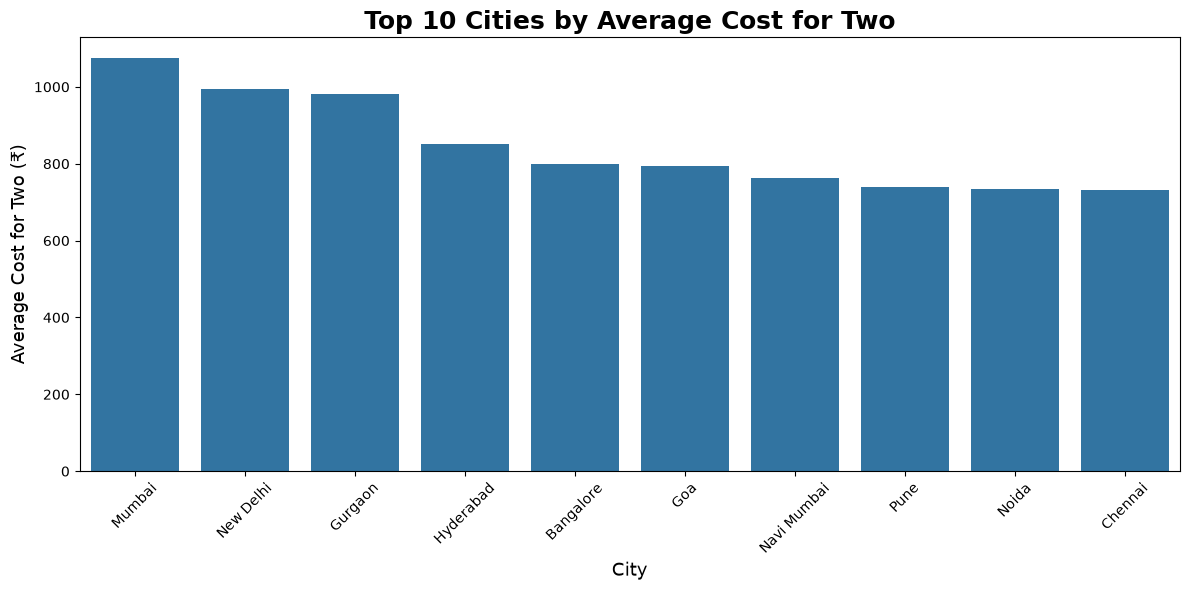

In [57]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=city_cost.index,
    y=city_cost.values
)

plt.title("Top 10 Cities by Average Cost for Two", fontsize=18, fontweight="bold")
plt.xlabel("City", fontsize=13)
plt.ylabel("Average Cost for Two (₹)", fontsize=13)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Analysis 7: City-wise Average Cost

### Business Question
Which cities have the highest average dining cost for two people?

### Observation
- The chart shows the top 10 cities with the highest average dining cost.
- Some metropolitan and tourist cities have significantly higher restaurant prices than others.

### Business Insight
Restaurant pricing varies across cities due to differences in customer spending power, tourism, and local market conditions. Businesses should adopt city-specific pricing strategies instead of using a uniform pricing model nationwide.

In [58]:
df["establishment"].head()

0    [
1    [
2    [
3    [
4    [
Name: establishment, dtype: str

In [59]:
df["establishment"].value_counts()

establishment
[    55568
Name: count, dtype: int64

In [61]:
df["establishment"].iloc[0]

'['

In [62]:
print(df["establishment"].iloc[0])

[


In [63]:
df[["name", "establishment"]].head(10)

,name,establishment
0,Bikanervala,[
1,Mama Chicken Mama Franky House,[
2,Bhagat Halwai,[
3,Bhagat Halwai,[
4,The Salt Cafe Kitchen & Bar,[
5,Domino's Pizza,[
6,Honeydew Restaurant,[
7,Domino's Pizza,[
8,Cake House,[
9,Sugar N Thyme,[


In [64]:
df.loc[0]

res_id                                                            3400299
name                                                          Bikanervala
establishment                                                           [
url                     https://www.zomato.com/agra/bikanervala-khanda...
address                 Kalyani Point, Near Tulsi Cinema, Bypass Road,...
city                                                                 Agra
city_id                                                                34
locality                                                         Khandari
latitude                                                         27.21145
longitude                                                       78.002381
zipcode                                                               NaN
country_id                                                              1
locality_verbose                                           Khandari, Agra
cuisines                North Indian, 

In [65]:
df = pd.read_csv("../data/zomato_raw.csv")

In [66]:
df = df.drop_duplicates(subset="res_id", keep="first")

In [67]:
df["establishment"].head()

0      ['Quick Bites']
1      ['Quick Bites']
2      ['Quick Bites']
3      ['Quick Bites']
4    ['Casual Dining']
Name: establishment, dtype: str

In [68]:
df["establishment"] = (
    df["establishment"]
    .str.strip("[]")
    .str.replace("'", "", regex=False)
)

In [69]:
df["establishment"].head()

0      Quick Bites
1      Quick Bites
2      Quick Bites
3      Quick Bites
4    Casual Dining
Name: establishment, dtype: str

In [70]:
df["establishment"].head()

0      Quick Bites
1      Quick Bites
2      Quick Bites
3      Quick Bites
4    Casual Dining
Name: establishment, dtype: str

In [71]:
top_establishments = df["establishment"].value_counts().head(10)

top_establishments

establishment
Quick Bites        14032
Casual Dining      12270
Café                4123
Bakery              3741
Dessert Parlour     3675
Sweet Shop          2615
Beverage Shop       2440
                    1830
Fine Dining         1535
Food Court          1494
Name: count, dtype: int64

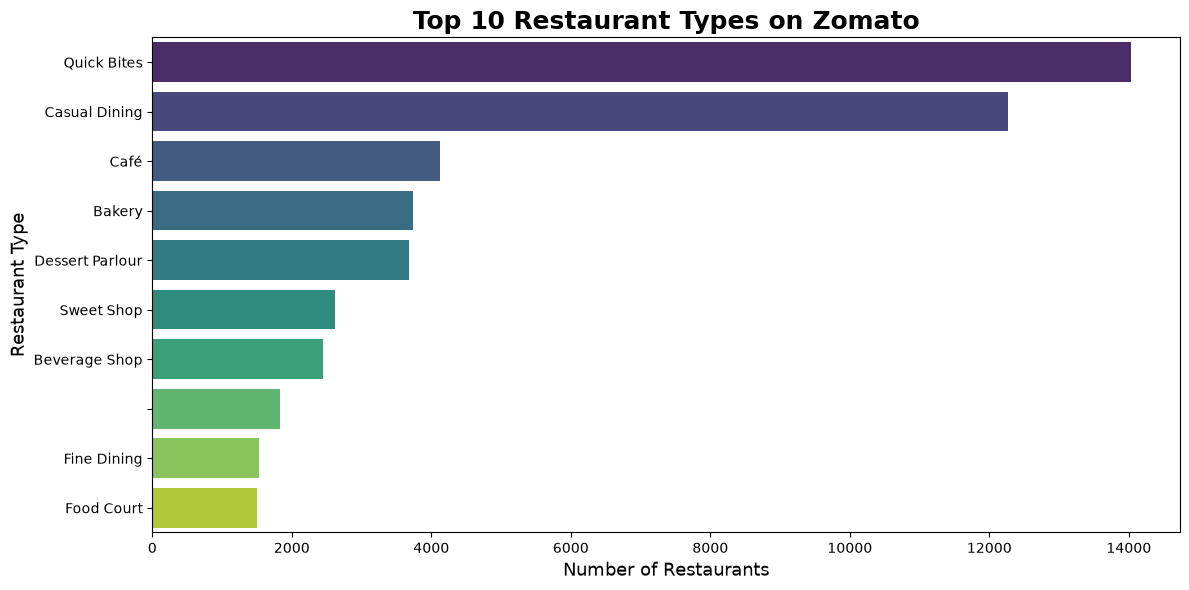

In [72]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_establishments.values,
    y=top_establishments.index,
    hue=top_establishments.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Restaurant Types on Zomato", fontsize=18, fontweight="bold")
plt.xlabel("Number of Restaurants", fontsize=13)
plt.ylabel("Restaurant Type", fontsize=13)

plt.tight_layout()
plt.show()

## Analysis 8: Restaurant Type Analysis

### Business Question
Which restaurant types dominate the Zomato platform?

### Why this analysis?
Understanding the distribution of restaurant types helps identify the most common business models in the food industry.

### Observation
- Quick Bites and Casual Dining dominate the platform.
- Cafés and Bakeries also have a significant presence.
- Premium restaurant formats are comparatively fewer.

### Business Insight
Most restaurants listed on Zomato belong to affordable and high-volume categories. Entrepreneurs entering the market may find greater demand in these segments, while premium dining targets a more niche customer base.

In [73]:
df[["votes", "aggregate_rating"]].head()

,votes,aggregate_rating
0,814,4.4
1,1203,4.4
2,801,4.2
3,693,4.3
4,470,4.9


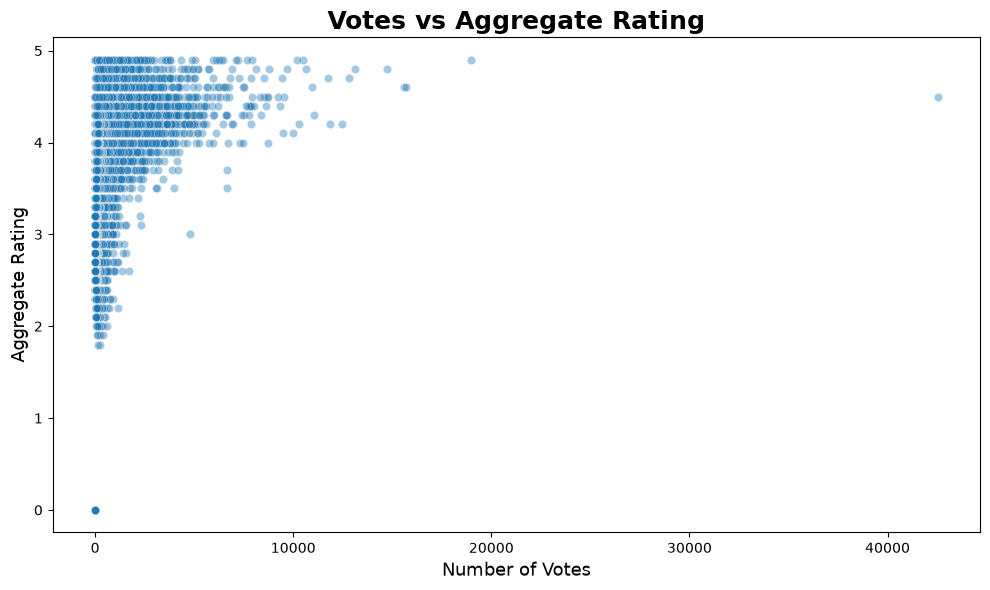

In [74]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="votes",
    y="aggregate_rating",
    alpha=0.4
)

plt.title("Votes vs Aggregate Rating", fontsize=18, fontweight="bold")
plt.xlabel("Number of Votes", fontsize=13)
plt.ylabel("Aggregate Rating", fontsize=13)

plt.tight_layout()
plt.show()

In [75]:
correlation = df["votes"].corr(df["aggregate_rating"])

print("Correlation:", round(correlation, 2))

Correlation: 0.28


## Analysis 9: Votes vs Rating

### Business Question
Do restaurants with more customer votes tend to have higher ratings?

### Why this analysis?
Customer votes represent popularity, while ratings represent satisfaction. Comparing them helps understand whether popular restaurants are also highly appreciated.

### Observation
- Restaurants with a large number of votes generally maintain good ratings.
- Many restaurants with few votes have ratings spread across a wider range.
- A few restaurants receive exceptionally high numbers of votes, acting as outliers.

### Business Insight
Popularity and customer satisfaction are positively related, but they are not the same. Restaurants can achieve high ratings with fewer votes, while highly popular restaurants often sustain good ratings through consistent service and quality.

In [76]:
numeric_df = df[
    [
        "average_cost_for_two",
        "price_range",
        "aggregate_rating",
        "votes",
        "photo_count"
    ]
]

In [77]:
corr_matrix = numeric_df.corr()

corr_matrix

,average_cost_for_two,price_range,aggregate_rating,votes,photo_count
average_cost_for_two,1.000000,0.791333,0.250045,0.263603,0.310848
price_range,0.791333,1.000000,0.252312,0.245646,0.283196
aggregate_rating,0.250045,0.252312,1.000000,0.283373,0.231655
votes,0.263603,0.245646,0.283373,1.000000,0.695668
photo_count,0.310848,0.283196,0.231655,0.695668,1.000000


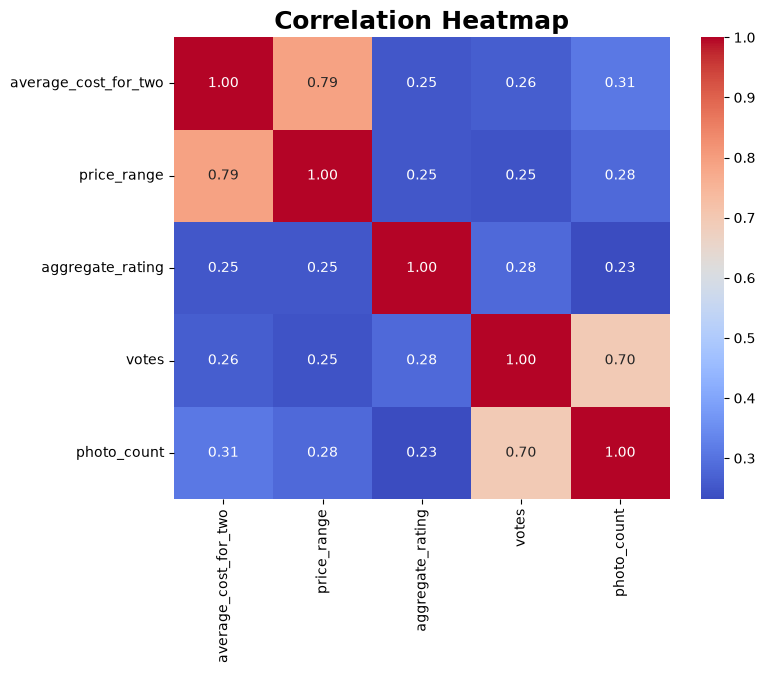

In [78]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=18, fontweight="bold")

plt.show()

## Analysis 10: Correlation Heatmap

### Business Question
How are the important numerical variables related to one another?

### Why this analysis?
A correlation heatmap provides an overview of relationships between multiple numerical variables at the same time.

### Observation
- Price Range and Average Cost for Two show a strong positive correlation.
- Votes and Photo Count are positively related, indicating that popular restaurants often have more customer photos.
- Aggregate Rating has only a moderate relationship with other variables.

### Business Insight
Restaurant popularity depends on multiple factors. Pricing influences cost-related metrics, while customer engagement (votes and photos) tends to move together. Ratings alone do not fully explain a restaurant's popularity.

In [79]:
df_clean = df.copy()

In [80]:
df_clean.columns

Index(['res_id', 'name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='str')

In [81]:
columns_to_drop = [
    "url",
    "address",
    "latitude",
    "longitude",
    "zipcode",
    "city_id",
    "country_id",
    "locality_verbose",
    "timings",
    "highlights",
    "opentable_support"
]

df_clean.drop(columns=columns_to_drop, inplace=True)

In [82]:
df_clean.head()

,res_id,name,establishment,city,locality,cuisines,average_cost_for_two,price_range,currency,aggregate_rating,rating_text,votes,photo_count,delivery,takeaway
0,3400299,Bikanervala,Quick Bites,Agra,Khandari,"North Indian, South Indian, Mithai, Street Foo...",700,2,Rs.,4.4,Very Good,814,154,-1,-1
1,3400005,Mama Chicken Mama Franky House,Quick Bites,Agra,Agra Cantt,"North Indian, Mughlai, Rolls, Chinese, Fast Fo...",600,2,Rs.,4.4,Very Good,1203,161,-1,-1
2,3401013,Bhagat Halwai,Quick Bites,Agra,Shahganj,"Fast Food, Mithai",300,1,Rs.,4.2,Very Good,801,107,1,-1
3,3400290,Bhagat Halwai,Quick Bites,Agra,Civil Lines,"Desserts, Bakery, Fast Food, South Indian",300,1,Rs.,4.3,Very Good,693,157,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,Casual Dining,Agra,Tajganj,"North Indian, Continental, Italian",1000,3,Rs.,4.9,Excellent,470,291,1,-1


In [83]:
df_clean.columns

Index(['res_id', 'name', 'establishment', 'city', 'locality', 'cuisines',
       'average_cost_for_two', 'price_range', 'currency', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'delivery', 'takeaway'],
      dtype='str')

In [84]:
df_clean.isnull().sum()

res_id                    0
name                      0
establishment             0
city                      0
locality                  0
cuisines                470
average_cost_for_two      0
price_range               0
currency                  0
aggregate_rating          0
rating_text               0
votes                     0
photo_count               0
delivery                  0
takeaway                  0
dtype: int64

In [85]:
df_clean["cuisines"] = df_clean["cuisines"].fillna("Unknown")
df_clean["rating_text"] = df_clean["rating_text"].fillna("Not Rated")

In [86]:
df_clean.isnull().sum()

res_id                  0
name                    0
establishment           0
city                    0
locality                0
cuisines                0
average_cost_for_two    0
price_range             0
currency                0
aggregate_rating        0
rating_text             0
votes                   0
photo_count             0
delivery                0
takeaway                0
dtype: int64

In [87]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 55568 entries, 0 to 211942
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   res_id                55568 non-null  int64  
 1   name                  55568 non-null  str    
 2   establishment         55568 non-null  str    
 3   city                  55568 non-null  str    
 4   locality              55568 non-null  str    
 5   cuisines              55568 non-null  str    
 6   average_cost_for_two  55568 non-null  int64  
 7   price_range           55568 non-null  int64  
 8   currency              55568 non-null  str    
 9   aggregate_rating      55568 non-null  float64
 10  rating_text           55568 non-null  str    
 11  votes                 55568 non-null  int64  
 12  photo_count           55568 non-null  int64  
 13  delivery              55568 non-null  int64  
 14  takeaway              55568 non-null  int64  
dtypes: float64(1), int64(7), str(7)
me

In [88]:
df_clean.to_csv("../data/zomato_cleaned.csv", index=False)

In [89]:
import os

os.listdir("../data")

['zomato_cleaned.csv', 'zomato_raw.csv']

# Final Cleaned Dataset

## Cleaning Performed

- Removed duplicate restaurants using `res_id`
- Handled missing values in important columns
- Removed unnecessary columns such as URL, Address, Latitude, Longitude, Zipcode, etc.
- Prepared a clean dataset for dashboard creation in Power BI

## Final Dataset

The cleaned dataset is exported as **zomato_cleaned.csv** and will be used for interactive dashboard development.